In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
CANDIDATES = [
    ROOT / "studentInfo.csv",
    ROOT / "open+university+learning+analytics+dataset" / "studentInfo.csv",
    ROOT / "oulad" / "studentInfo.csv",
    ROOT / "oulad" / "studentAssessment.csv",
    ROOT/ "oulad" / "studentVle.csv",
    ROOT / "oulad" / "vle.csv",
    ROOT / "oulad" / "courses.csv",
    ROOT / "oulad" / "studentRegistration.csv",
    ROOT / "oulad" / "assessments.csv",
]

student_info_path = next((path for path in CANDIDATES if path.exists()), None)
if student_info_path is None:
    raise FileNotFoundError("Could not find studentInfo.csv in expected folders.")

In [3]:
student_info = pd.read_csv(student_info_path)
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [4]:
student_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [49]:
student_info.shape
student_info.isnull().sum()

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

In [5]:
# finding rows with any "?" values anywhere in the dataframe. 
# This is useful for identifying missing or placeholder values that need to be cleaned or handled before analysis.
student_info[student_info.eq("?").any(axis=1)]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,?,55<=,0,60,N,Pass
17,AAA,2013J,71361,M,Ireland,HE Qualification,?,35-55,0,60,N,Pass
28,AAA,2013J,104476,M,Ireland,Post Graduate Qualification,?,35-55,0,60,N,Pass
34,AAA,2013J,114017,F,North Region,Post Graduate Qualification,?,35-55,0,60,N,Pass
65,AAA,2013J,172112,M,Ireland,HE Qualification,?,35-55,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
30552,GGG,2013J,589914,M,North Region,Lower Than A Level,?,0-35,0,30,N,Pass
31170,GGG,2014B,575199,F,North Western Region,Lower Than A Level,?,0-35,0,30,N,Pass
31389,GGG,2014B,617889,F,South West Region,Lower Than A Level,?,0-35,0,30,N,Fail
31777,GGG,2014B,634470,F,South Region,A Level or Equivalent,?,0-35,0,30,N,Distinction


In [6]:
student_info['imd_band'] = student_info['imd_band'].replace("?", 'unknown')
student_info['imd_band']

0        90-100%
1         20-30%
2         30-40%
3         50-60%
4         50-60%
          ...   
32588      10-20
32589     40-50%
32590     20-30%
32591    90-100%
32592     50-60%
Name: imd_band, Length: 32593, dtype: object

In [52]:
student_info.describe(include = 'all')
# student_info["code_module"].describe()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,32593,32593,3.259300e+04,32593,32593,32593,32593,32593,32593.000000,32593.000000,32593,32593
unique,7,4,NaN,2,13,5,11,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN


In [8]:
top_credits = student_info.sort_values('studied_credits', ascending=False)
top_credits

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
2778,BBB,2013J,363151,M,North Western Region,Lower Than A Level,10-20,35-55,0,655,Y,Withdrawn
10378,CCC,2014B,1474869,F,South Region,A Level or Equivalent,90-100%,35-55,0,630,Y,Pass
865,BBB,2013B,230348,F,East Anglian Region,A Level or Equivalent,0-10%,0-35,2,585,N,Withdrawn
16424,DDD,2014B,244438,M,North Western Region,A Level or Equivalent,10-20,0-35,1,540,N,Withdrawn
11315,CCC,2014J,556788,M,North Region,Lower Than A Level,unknown,35-55,1,480,N,Withdrawn
...,...,...,...,...,...,...,...,...,...,...,...,...
20066,EEE,2013J,591869,M,North Region,HE Qualification,unknown,0-35,0,30,N,Pass
20059,EEE,2013J,591178,M,Yorkshire Region,HE Qualification,60-70%,0-35,0,30,N,Withdrawn
20058,EEE,2013J,591165,M,Scotland,Lower Than A Level,10-20,0-35,0,30,N,Fail
20054,EEE,2013J,590882,M,South Region,Lower Than A Level,70-80%,0-35,0,30,N,Pass


In [9]:
(student_info['studied_credits']>300).sum()


np.int64(35)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Pass'),
  Text(1, 0, 'Withdrawn'),
  Text(2, 0, 'Fail'),
  Text(3, 0, 'Distinction')])

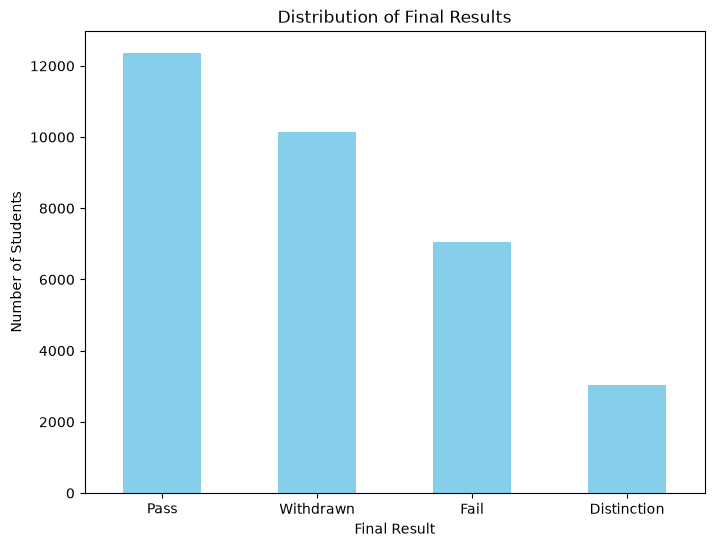

In [10]:
#bar chart for final result distribution
final_result_counts = student_info['final_result'].value_counts()
plt.figure(figsize=(8, 6))
final_result_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Final Results')
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)

In [11]:
#check gender vs final result
#does final result relate to any demographic factors like gender, age, or socioeconomic status? We can explore this by creating visualizations and performing statistical tests to see if there are significant differences in final results based on these factors.
gender_final_result_counts = student_info.groupby(['gender', 'final_result']).size().unstack()
gender_final_result_counts

final_result,Distinction,Fail,Pass,Withdrawn
gender,,,,
F,1394,3103,5735,4486
M,1630,3949,6626,5670


In [12]:
assessments_path = ROOT / "oulad" / "assessments.csv"
assessments = pd.read_csv(assessments_path)
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


In [13]:
assessments_path = ROOT / "oulad" / "assessments.csv"
assessments = pd.read_csv(assessments_path)
assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    object 
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 9.8+ KB


In [14]:
student_assessments_path = ROOT / "oulad" / "studentAssessment.csv"
student_assessments = pd.read_csv(student_assessments_path)
student_assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_assessment   173912 non-null  int64 
 1   id_student      173912 non-null  int64 
 2   date_submitted  173912 non-null  int64 
 3   is_banked       173912 non-null  int64 
 4   score           173912 non-null  object
dtypes: int64(4), object(1)
memory usage: 6.6+ MB


In [15]:
#merge student_assessment with assessments to get assessment details for each student
mergeStudentAssessments = pd.merge(student_assessments, assessments, on='id_assessment', how='left')
mergeStudentAssessments.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78,AAA,2013J,TMA,19,10.0
1,1752,28400,22,0,70,AAA,2013J,TMA,19,10.0
2,1752,31604,17,0,72,AAA,2013J,TMA,19,10.0
3,1752,32885,26,0,69,AAA,2013J,TMA,19,10.0
4,1752,38053,19,0,79,AAA,2013J,TMA,19,10.0


When we ran the left join earlier, full_data["final_result"].isnull().sum() came back as 0. That means every single score row already had a matching student in student_info. So in this specific case:
Inner join and left join will give you the exact same result — same row count, same data. Neither drops anything, because there was nothing unmatched to drop.

In [16]:
#merge StudentAssessments with student info
mergeStudentInfo = pd.merge(mergeStudentAssessments, student_info, on = ['id_student', 'code_module', 'code_presentation'], how = 'inner')
mergeStudentInfo.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,1752,11391,18,0,78,AAA,2013J,TMA,19,10.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,1752,28400,22,0,70,AAA,2013J,TMA,19,10.0,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,1752,31604,17,0,72,AAA,2013J,TMA,19,10.0,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
3,1752,32885,26,0,69,AAA,2013J,TMA,19,10.0,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
4,1752,38053,19,0,79,AAA,2013J,TMA,19,10.0,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass


In [17]:
#count null values 
mergeStudentInfo.isnull().sum()
# #sanity merge check
len(mergeStudentAssessments)
len(mergeStudentInfo)

173912

In [18]:
student_vle_path = ROOT / "oulad" / "studentVle.csv"
student_Vle = pd.read_csv(student_vle_path)
student_Vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


In [19]:
student_Vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [60]:
# generate click totals per student-course presentation
student_Vle["sum_click"].sum()
click_per_student = student_Vle.groupby(
    ["id_student", "code_module", "code_presentation"]
 )["sum_click"].sum()
click_per_student

id_student  code_module  code_presentation
6516        AAA          2014J                2791
8462        DDD          2013J                 646
                         2014J                  10
11391       AAA          2013J                 934
23629       BBB          2013B                 161
                                              ... 
2698257     AAA          2013J                 758
2698535     CCC          2014B                 786
            EEE          2013J                3455
2698577     BBB          2014J                 717
2698588     BBB          2014J                 605
Name: sum_click, Length: 29228, dtype: int64

In [61]:
early_engagement = student_Vle.groupby(["id_student", "code_module", "code_presentation"]).agg(engaged_before_start = ('date', lambda x: (x < 0).any())).reset_index()
early_engagement

,id_student,code_module,code_presentation,engaged_before_start
0,6516,AAA,2014J,True
1,8462,DDD,2013J,True
2,8462,DDD,2014J,False
3,11391,AAA,2013J,True
4,23629,BBB,2013B,True
...,...,...,...,...
29223,2698257,AAA,2013J,True
29224,2698535,CCC,2014B,True
29225,2698535,EEE,2013J,True
29226,2698577,BBB,2014J,False


In [62]:
if "engaged_before_start" not in mergeStudentInfo.columns:
    mergeStudentInfo = mergeStudentInfo.merge(
        early_engagement,
        on=["id_student", "code_module", "code_presentation"],
        how="left",
    )

mergeStudentInfo["engaged_before_start"] = mergeStudentInfo["engaged_before_start"].fillna(False)
mergeStudentInfo[["id_student", "code_module", "code_presentation", "engaged_before_start"]].head()

,id_student,code_module,code_presentation,engaged_before_start
0,11391,AAA,2013J,True
1,28400,AAA,2013J,True
2,31604,AAA,2013J,True
3,32885,AAA,2013J,True
4,38053,AAA,2013J,True


In [53]:
mergeStudentInfo[["id_student", "code_module", "code_presentation", "final_result", "engaged_before_start"]]

,id_student,code_module,code_presentation,final_result,engaged_before_start
0,11391,AAA,2013J,Pass,True
1,28400,AAA,2013J,Pass,True
2,31604,AAA,2013J,Pass,True
3,32885,AAA,2013J,Pass,True
4,38053,AAA,2013J,Pass,True
...,...,...,...,...,...
173907,527538,GGG,2014J,Distinction,False
173908,534672,GGG,2014J,Pass,True
173909,546286,GGG,2014J,Distinction,True
173910,546724,GGG,2014J,Pass,False


In [63]:
# mergeStudentInfo.info()
# could a third pattern explain this pattern rather than one variable causing the other?
resultingEngagement = (
    student_Vle.assign(date_num=pd.to_numeric(student_Vle["date"], errors="coerce"))
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .agg(engaged_before_start=("date_num", lambda x: (x < 0).any()))
)
resultingEngagement.head()

,id_student,code_module,code_presentation,engaged_before_start
0,6516,AAA,2014J,True
1,8462,DDD,2013J,True
2,8462,DDD,2014J,False
3,11391,AAA,2013J,True
4,23629,BBB,2013B,True


In [64]:
engagement_with_result = pd.merge(
    resultingEngagement,
    mergeStudentInfo[["id_student", "code_module", "code_presentation", "final_result"]].drop_duplicates(),
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)

pd.crosstab(
    engagement_with_result["engaged_before_start"],
    engagement_with_result["final_result"],
    normalize="index",
) * 100

final_result,Distinction,Fail,Pass,Withdrawn
engaged_before_start,,,,
False,7.010078,32.161254,42.374020,18.454647
True,12.710990,20.180045,49.062266,18.046699


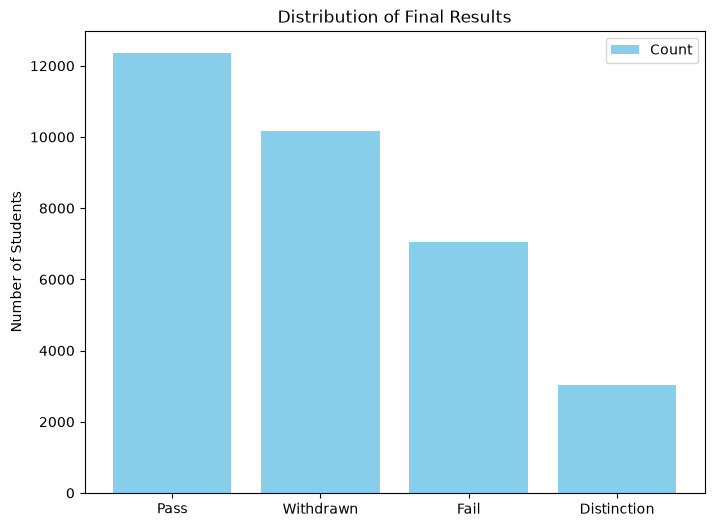

In [65]:
final_result_counts = student_info["final_result"].value_counts()
positions = np.arange(len(final_result_counts))

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(positions, final_result_counts.values, color="skyblue", label="Count")
ax.set_xticks(positions)
ax.set_xticklabels(final_result_counts.index)
ax.set_ylabel("Number of Students")
ax.set_title("Distribution of Final Results")
ax.legend()
plt.show()

In [66]:
# Compare two definitions of "not engaged early":
# 1) Excluding never-clicked students
# 2) Including never-clicked students as engaged_before_start = False

student_course_results = student_info[
    ["id_student", "code_module", "code_presentation", "final_result"]
].drop_duplicates()

# Version A: exclude students with no VLE records
exclude_never = pd.merge(
    resultingEngagement,
    student_course_results,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)

pct_exclude_never = pd.crosstab(
    exclude_never["engaged_before_start"],
    exclude_never["final_result"],
    normalize="index",
) * 100

# Version B: include students with no VLE records as False
include_never = pd.merge(
    student_course_results,
    resultingEngagement[[
        "id_student", "code_module", "code_presentation", "engaged_before_start"
    ]],
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
include_never["engaged_before_start"] = include_never["engaged_before_start"].fillna(False)

pct_include_never = pd.crosstab(
    include_never["engaged_before_start"],
    include_never["final_result"],
    normalize="index",
) * 100

comparison_pct = pd.concat(
    {
        "Exclude Never-Clicked": pct_exclude_never.round(2),
        "Include Never-Clicked as False": pct_include_never.round(2),
    },
    axis=0,
 )

comparison_pct

/var/folders/ys/3zq8g6910md1q2zt7zps4bnc0000gn/T/ipykernel_17369/875690053.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  include_never["engaged_before_start"] = include_never["engaged_before_start"].fillna(False)


final_result                                         Distinction   Fail  \
                               engaged_before_start                       
Exclude Never-Clicked          False                        5.78  33.35   
                               True                        11.39  20.46   
Include Never-Clicked as False False                        3.56  24.83   
                               True                        11.39  20.46   

final_result                                          Pass  Withdrawn  
                               engaged_before_start                    
Exclude Never-Clicked          False                 34.93      25.95  
                               True                  43.95      24.20  
Include Never-Clicked as False False                 21.58      50.02  
                               True                  43.95      24.20

In [72]:
engagement_features = student_Vle.groupby(["id_student", "code_module", "code_presentation"]).agg(total_clicks=("sum_click", "sum"), active_days= ("date", "nunique"),).reset_index()
engagement_features

,id_student,code_module,code_presentation,total_clicks,active_days
0,6516,AAA,2014J,2791,159
1,8462,DDD,2013J,646,56
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,934,40
4,23629,BBB,2013B,161,16
...,...,...,...,...,...
29223,2698257,AAA,2013J,758,69
29224,2698535,CCC,2014B,786,34
29225,2698535,EEE,2013J,3455,110
29226,2698577,BBB,2014J,717,37


In [84]:
student_info_engagement = pd.merge(student_info, engagement_features, on = ["id_student", "code_module", "code_presentation"], how = "left")
student_info_engagement

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,41.0,5.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,893.0,45.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,312.0,24.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,275.0,13.0


In [90]:
if not isinstance(student_info_engagement, pd.DataFrame) or not {"total_clicks", "active_days"}.issubset(student_info_engagement.columns):
    student_info_engagement = pd.merge(
        student_info,
        engagement_features,
        on=["id_student", "code_module", "code_presentation"],
        how="left",
    )

student_info_engagement["total_clicks"] = student_info_engagement["total_clicks"].fillna(0)
student_info_engagement["active_days"] = student_info_engagement["active_days"].fillna(0)

student_info_engagement

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,41.0,5.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,893.0,45.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,312.0,24.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,275.0,13.0


In [91]:
#does engagement differ by outcome?
student_info_engagement.groupby("final_result")[["total_clicks", "active_days"]].mean().round(1).sort_values("total_clicks", ascending=False)

,total_clicks,active_days
final_result,,
Distinction,2666.8,110.0
Pass,1921.8,87.0
Fail,651.9,33.2
Withdrawn,314.0,16.3


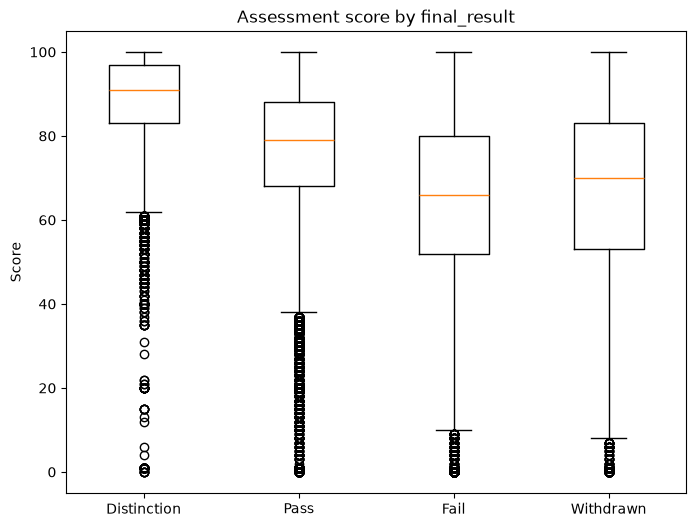

In [ ]:
#boxplot score by final_result
mergeStudentInfo["score"] = pd.to_numeric(mergeStudentInfo["score"], errors = "coerce")
categories = ["Distinction", "Pass", "Fail", "Withdrawn"]
data_by_category = [mergeStudentInfo.loc[mergeStudentInfo["final_result"] == cat, "score"].dropna() for cat in categories]

fig, ax = plt.subplots(figsize=(8,6))
ax. boxplot(data_by_category, tick_labels=categories)
ax.set_title("Assessment score by final_result")
ax.set_ylabel("Score")
plt.show()

In [100]:
mergeStudentInfo.describe()

,id_assessment,id_student,date_submitted,is_banked,score,weight,num_of_prev_attempts,studied_credits
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000,173912.000000,173912.000000,173912.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573,12.743899,0.144907,76.779147
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107,17.877301,0.445326,37.341741
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000,0.000000,0.000000,60.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000,9.000000,0.000000,60.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000,18.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000,100.000000,6.000000,630.000000


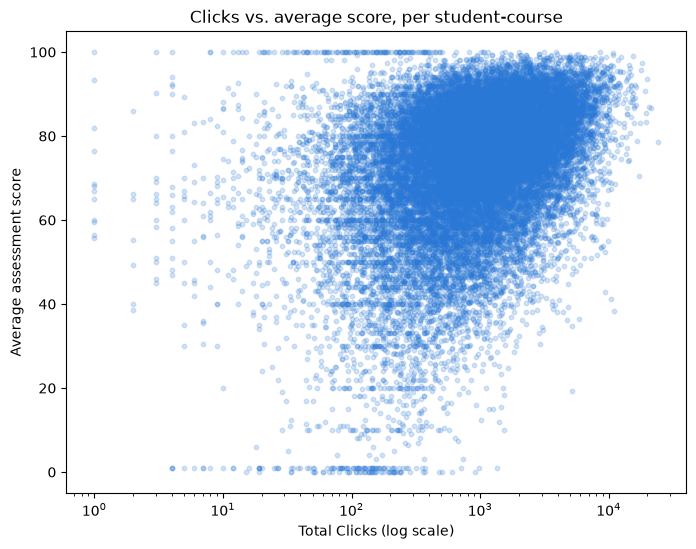

In [101]:
# scatterplot click vs score
avg_score = mergeStudentInfo.groupby(["id_student", "code_module", "code_presentation"])["score"].mean().reset_index()
avg_score = avg_score.rename(columns={"score": "avg_score"})

clicks_vs_score = pd.merge(avg_score, engagement_features[["id_student", "code_module", "code_presentation", "total_clicks"]], 
                           on = ["id_student", "code_module", "code_presentation"], how = "inner").dropna()

fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(clicks_vs_score["total_clicks"], clicks_vs_score["avg_score"], alpha = 0.2, s=10, color="#2a78d6")
ax.set_xscale("log")
ax.set_xlabel("Total Clicks (log scale)")
ax.set_ylabel("Average assessment score")
ax.set_title("Clicks vs. average score, per student-course")
plt.show()


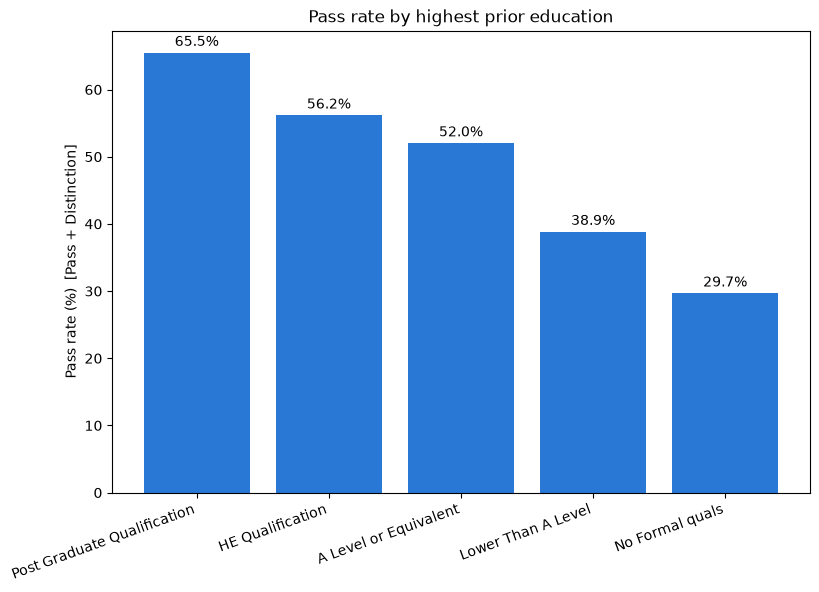

In [102]:
#grouped bar charts pass rate by region or education level
student_info["passed"] = student_info["final_result"].isin(["Pass", "Distinction"])
pass_rate_by_education = (student_info.groupby("highest_education")["passed"].mean() *100).sort_values(ascending = False)
fig, ax = plt.subplots(figsize=(9,6))
positions = np.arange(len(pass_rate_by_education))
bars = ax.bar(positions, pass_rate_by_education.values, color="#2a78d6")
ax.set_xticks(positions)
ax.set_xticklabels(pass_rate_by_education.index, rotation=20, ha="right")
ax.set_ylabel("Pass rate (%)  [Pass + Distinction]")
ax.set_title("Pass rate by highest prior education")
for bar, value in zip(bars, pass_rate_by_education.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.1f}%", ha="center")
plt.show()

In [104]:
clicks_vs_score[["total_clicks", "avg_score"]].corr()

,total_clicks,avg_score
total_clicks,1.000000,0.293254
avg_score,0.293254,1.000000


In [107]:
clicks_vs_score[["total_clicks", "avg_score"]].corr()

,total_clicks,avg_score
total_clicks,1.000000,0.293254
avg_score,0.293254,1.000000


In [115]:
#merge everything done so far in a master table
master = student_info.merge(engagement_features, on = ["id_student", "code_module", "code_presentation"], how = "left")
master = master.merge(avg_score, on = ["id_student", "code_module", "code_presentation"], how = "left")
master["total_clicks"] = master["total_clicks"].fillna(0)
master["active_days"] = master["active_days"].fillna(0)
master = master.merge(
    early_engagement[["id_student", "code_module", "code_presentation", "engaged_before_start"]],
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
master["engaged_before_start"] = master["engaged_before_start"].fillna(False)
master

/var/folders/ys/3zq8g6910md1q2zt7zps4bnc0000gn/T/ipykernel_17369/1921835896.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master["engaged_before_start"] = master["engaged_before_start"].fillna(False)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,total_clicks,active_days,avg_score,engaged_before_start
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,True,934.0,40.0,82.000000,True
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,True,1435.0,80.0,66.400000,True
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,False,281.0,12.0,NaN,True
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,True,2158.0,123.0,76.000000,True
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,True,1034.0,70.0,54.400000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,False,41.0,5.0,NaN,True
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,True,893.0,45.0,88.111111,False
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,True,312.0,24.0,76.666667,True
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,False,275.0,13.0,91.500000,True


In [123]:
# engineer a new feature -- submission timelines -- were assessments submitted early or late relative to the deadline   
assessments["date"] = pd.to_numeric(assessments["date"], errors = "coerce")
merged = pd.merge(
    student_assessments,
    assessments[["id_assessment", "code_module", "code_presentation", "date"]],
    on="id_assessment",
    how="left"
)
merged["days_late"] = merged["date_submitted"] - merged["date"]
timeliness = merged.groupby(["id_student", "code_module", "code_presentation"]).agg(
    avg_days_late=("days_late", "mean"),
    num_late_submissions=("days_late", lambda x: (x > 0).sum())
).reset_index()
timeliness


,id_student,code_module,code_presentation,avg_days_late,num_late_submissions
0,6516,AAA,2014J,-2.600000,0
1,8462,DDD,2013J,-0.333333,1
2,8462,DDD,2014J,-59.500000,0
3,11391,AAA,2013J,-1.800000,0
4,23629,BBB,2013B,3.500000,3
...,...,...,...,...,...
25838,2698257,AAA,2013J,2.000000,2
25839,2698535,CCC,2014B,1.500000,3
25840,2698535,EEE,2013J,2.250000,1
25841,2698577,BBB,2014J,-1.000000,0


In [128]:
# engineer another: assessment completion rate -- did the student attempt all their assigned assessments or skip some?
assigned_counts = assessments.groupby(["code_module", "code_presentation"]).size().reset_index(name="num_assigned")
submitted_counts = merged.groupby(["id_student", "code_module", "code_presentation"]).size().reset_index(name="num_submitted")
completion = pd.merge(submitted_counts, assigned_counts, on=["code_module", "code_presentation"], how="left")
completion["completed_rate"] = completion["num_submitted"] / completion["num_assigned"]

#combine everything and validate against final_results
master = master.drop(
    columns=[
        "avg_days_late",
        "num_late_submissions",
        "completion_rate",
        "avg_days_late_x",
        "num_late_submissions_x",
        "avg_days_late_y",
        "num_late_submissions_y",
    ],
    errors="ignore",
)

master = master.merge(
    timeliness,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
master = master.merge(
    completion[["id_student", "code_module", "code_presentation", "completed_rate"]].rename(
        columns={"completed_rate": "completion_rate"}
    ),
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
master.groupby("final_result")[["avg_days_late", "num_late_submissions", "completion_rate"]].mean().round(2)
master

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,total_clicks,active_days,avg_score,engaged_before_start,avg_days_late,num_late_submissions,completion_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,True,934.0,40.0,82.000000,True,-1.800000,0.0,0.833333
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,True,1435.0,80.0,66.400000,True,0.000000,2.0,0.833333
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,False,281.0,12.0,NaN,True,NaN,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,True,2158.0,123.0,76.000000,True,-2.000000,0.0,0.833333
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,True,1034.0,70.0,54.400000,True,11.400000,5.0,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,False,41.0,5.0,NaN,True,NaN,NaN,NaN
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,True,893.0,45.0,88.111111,False,-36.222222,2.0,0.900000
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,True,312.0,24.0,76.666667,True,-45.333333,0.0,0.900000
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,False,275.0,13.0,91.500000,True,-79.500000,0.0,0.200000


In [133]:
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np

In [132]:
#chi-square test
#engaged_before_Start actually related to final_result or could that pattern have happened by chance
contigency_table = pd.crosstab(master["engaged_before_start"], master["final_result"])
chi2_stat, p_value, dof, expected = chi2_contingency(contigency_table)
print(f"chi2 = {chi2_stat:2f}, p = {p_value: .2e}")

n = contigency_table.sum().sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contigency_table.shape) - 1)))
print(f"Cramér's V: {cramers_v:.3f}")

chi2 = 2699.573878, p =  0.00e+00
Cramér's V: 0.288


In [134]:
#independent t-test
# do pass and withdrawn students have genuinely different average total_clicks or is the 1900 vs 314 difference not as solid as it looks

pass_clicks = master.loc[master["final_result"]=="Pass", "total_clicks"]
withdrawn_clicks = master.loc[master["final_result"]=="Withdrawn", "total_clicks"]
t_stat, p_value = ttest_ind(pass_clicks, withdrawn_clicks, equal_var=False)
print(f"t={t_stat:.2f}, p={p_value:.2e}")

t=90.71, p=0.00e+00



 ## Summary of Findings — OULAD Exploratory Analysis

 ### Dataset overview
 - 32,593 student-course enrollments across 7 modules and multiple presentations
 - Outcomes: 38% Pass, 31% Withdrawn, 22% Fail, 9% Distinction
 - Data quality: OULAD uses `"?"` as a placeholder for missing values across
   multiple files (`imd_band`, assessment `score`, assessment `date`) - always
   checked and converted before doing numeric work

 ### Key findings

 **1. VLE engagement is the strongest signal found in this analysis.**
 Students who passed clicked ~1,922 times on average (87 active days);
 withdrawn students clicked only ~314 times (16 active days) - roughly a
 6x gap. Confirmed with a Welch's t-test (p ≈ 0), not just a raw average.

 **2. Engaging with the VLE *before* the course officially started
 is associated with much better outcomes.** 44% of early engagers passed,
 vs. 21.6% of everyone else; withdrawal dropped from 50% to 24%.
 Confirmed with a chi-square test (p ≈ 0, Cramér's V = 0.288 - a real
 but moderate relationship). Likely reflects underlying student motivation
 rather than early-login itself causing success - correlation, not proof
 of causation.

 **3. Assessment completion rate tracks outcome almost by definition.**
 Pass/Distinction students complete ~87-88% of assessments; Withdrawn
 students complete only 29% - consistent with withdrawal meaning
 "stopped partway through."

 **4. Prior education level predicts pass rate, but the relationship
 is moderate, not dominant.** Pass rate rises from 29.7% (No Formal
 quals) to 65.5% (Post Graduate) - though the two extreme groups have
 small sample sizes (313-347 students) and are less reliable than the
 middle categories (13-14k students each).

 **5. Clicks and assessment score are only weakly correlated (r = 0.29).**
 Engagement predicts *completing/passing* far better than it predicts
 the actual *score* a student earns - two different things.

 **6. Gender showed almost no relationship with outcome**
 (39.0% vs 37.1% pass rate) - one of the few factors ruled out
 rather than confirmed.

 **7. `imd_band` missingness is not random** - it clusters heavily in
 North Region (40%) and Ireland (22.5%), likely reflecting that
 England's deprivation index doesn't map cleanly onto other UK regions -
 handled by encoding it as an explicit "Unknown" category rather than
 dropping rows or treating it as random.

 ### Caveats
 - All relationships found are correlational; no causal claims can be
   made from this analysis alone
 - Engagement metrics (clicks, active days) are themselves *outcomes*
   of student behavior, not independent causes - a predictive model
   built on them would really be modeling "engaged students tend to
   succeed," which is close to circular for a course still in progress
 - Sample sizes vary a lot across subgroups (education level, region) -
   always check group sizes before trusting a percentage